In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from neuralnet import avg_fidelity_loss, avg_norm_loss, mse_cyclic_2 
import math
import cv2

from dataGenNew import generate_random_function, Ugen, rand_En, rand_costheta, rand_phi, full_measure

import tensorflow as tf
import time 

# Load experimental data

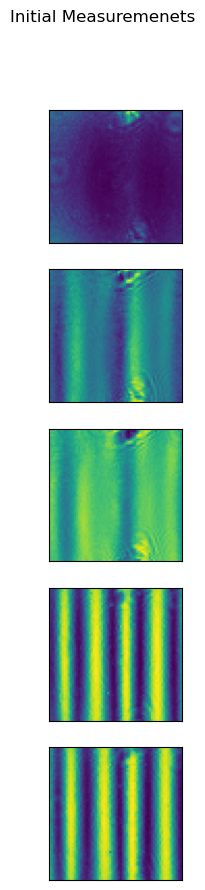

In [2]:
## Names of processes ##
# Tx(pi)WTx(pi2)WTx(pi2)
# Tx(pi)
# Ty(pi2)Tx(pi2)W
# S1x(pi)W
# S2x(pi)WS1y(pi)

process_num = 1
process_list = {1:"Tx(pi)", 2:"Ty(pi2)Tx(pi2)W", 3:"Tx(pi)WTx(pi2)WTx(pi2)", 4:"S1x(pi)W", 5:"S2x(pi)WS1y(pi)", 6:"QPlate"}

process_unnamed = process_list[process_num]
process = "/" + process_unnamed

num_pix = 64
path = "experimental_data"

LL = np.loadtxt(path+process+f"/LL{num_pix}.txt")
LH = np.loadtxt(path+process+f"/LH{num_pix}.txt")
LD = np.loadtxt(path+process+f"/LD{num_pix}.txt")
HH = np.loadtxt(path+process+f"/HH{num_pix}.txt")
HD = np.loadtxt(path+process+f"/HD{num_pix}.txt")

# Create matrix for measurements 

X = np.zeros([num_pix,num_pix,5])
X[:,:,0] = LL
X[:,:,1] = LH
X[:,:,2] = LD
X[:,:,3] = HH
X[:,:,4] = HD

# We can plot these, I guess

fig, ax = plt.subplots(5,1, figsize=(10,10))

plt.suptitle('Initial Measuremenets')
ax[0].imshow(X[:,:,0]) 
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].imshow(X[:,:,1]) 
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

ax[2].imshow(X[:,:,2]) 
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

ax[3].imshow(X[:,:,3])
ax[3].get_xaxis().set_visible(False)
ax[3].get_yaxis().set_visible(False)

ax[4].imshow(X[:,:,4])
ax[4].get_xaxis().set_visible(False)
ax[4].get_yaxis().set_visible(False)


# Load the trained neural network

In [ ]:
# Load model checkpoint 

mol_64 = 'network64_30'
mol_128 = 'network128_8batch'
mol_128_16 = 'network128_16batch'
mol_128_uniform= 'network128_uniform'
mol_128_uniPer = 'network128_uniform_new'
mol_128_new = '128Net_Uni'
mol_128_fixed = '128Net_Fixed'

mol_16_cycleLoss = '16Net_cycleMSE_100k'
mol_16_poly = '16Net_npoly'
mol_16_linear = '16Net_linear5'
mol_16_ctop = '16Net_cartToPoly'

mol_64_oneDim = '64Net_oneDim'
mol_64_allRand_50k = '64Net_allRand_50k'
mol_64_allRand_50k_32U = '64Net_allRand_50k_32U'
mol_64_allRand_25k = '64Net_allRand'
mol_64_allRand_100k = '64Net_allRand_100k'
mol_64_allRand_three = '64Net_allRand_three'

mol_32_cycleLoss = '32Net_cycleMSE_100k'
mol_64_cycleLoss = '64Net_16U_20k'
mol_128_cycleLoss = '128Net_16U_10k'
mol_128_ctop = '128Net_fromCart'

mol_32_allRand_oneFourier = '32Net_allRand_oneFourier'
mol_32_allRand_twoFourier = '32Net_allRand_twoFourier'
mol_32_allRand_threeFourier = '32Net_allRand_threeFourier'
mol_32_allRand_fourFourier = '32Net_allRand_fourFourier'
mol_32_allRand_fiveFourier = '32Net_allRand_fiveFourier'


mol_64_five = '64Net_allRand_five'
mol_64_five_32U = '64Net_allRand_five_32U'
mol_64_five_64U = '64Net_allRand_five_64U'

mol_64_gplate = '64Net_GPlate'

mol_64_oneGen = '64Net_withDatagen_one'
mol_metalRules = '64Net_heavyMetal_enhanced'
mol_metalDataGen = '64Net_fullMetaDataGen'
mol_heavyMetalGplate = '64Net_hevayMetalGPlatesFixed'

mol_64_threeLay = '64Net_threeLay'

mol_64_twoFourier= '64Net_twoFourier'
mol_64_threeFourier = '64Net_threeFourier'
mol_moreLayers = '64Net_heavyMetal_100k_moreLay'
mol_50k_moreLayers = '64Net_heavyMetal_50k'

mol_100k_moreLay = '64Net_heavyMetal_100k_moreLay'
mol_100k_fixedGen = '64Net_fullMetaDataGen'
mol_100k_four = '64Net_heavyMetal_50k_four'

loaded_model = tf.keras.models.load_model(mol_100k_four, custom_objects={'math': math, 'minMean': avg_fidelity_loss, 'minMeanNormal':avg_norm_loss, 'mse_cyclic_2':mse_cyclic_2}, compile=True)

# Prompt the network to make predictions and perform unitary matrix reconstruction

In [ ]:
full_meas_enhance = tf.expand_dims(X, axis=0)

# Initiate predictions
start_time = time.time()
y_pred=loaded_model.predict(full_meas_enhance)
fin_time = time.time() - start_time
print(fin_time)
np.shape(y_pred)

y_exp = y_pred

En_exp = y_pred[0,:,:,0]
nx_exp = np.sin(y_pred[0,:,:,1])*np.cos(y_pred[0,:,:,2])
ny_exp = np.sin(y_pred[0,:,:,1])*np.sin(y_pred[0,:,:,2])
nz_exp = np.cos(y_pred[0,:,:,1])

a1_pred = y_pred[0,:,:,0]
a2_pred = y_pred[0,:,:,1]
a3_pred = y_pred[0,:,:,2]


# Plot the reconstructions

In [ ]:
# Transpose the matrix

En_exp_t = np.transpose(En_exp)
nx_exp_t = np.transpose(nx_exp)
ny_exp_t = np.transpose(ny_exp)
nz_exp_t = np.transpose(nz_exp)

# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minNx = -1
maxNx = 1

minNy = -1
maxNy = 1

minNz = -1
maxNz = 1

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(1,4,figsize=(20, 5))
y,x=np.meshgrid(kxvals,kyvals)


c = ax[0].pcolormesh(x, y, En_exp_t[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0])

c2 = ax[1].pcolormesh(x, y, nx_exp_t[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1])

c3 = ax[2].pcolormesh(x, y, ny_exp_t[:-1,:-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2])

c4 = ax[3].pcolormesh(x, y, nz_exp_t[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[3])

#plt.savefig(f'experimental_{num_pix}' + process_unnamed + '.png')

# An aside: let us compute the average error

Start by computing the 'numerical' average measurements

In [ ]:
num_pix = 64
noise = 0.01
stateNoise = 0.00
full_meas_pred = full_measure(a1_pred,a2_pred,a3_pred,num_pix,noise,stateNoise)

In [ ]:
fig, ax = plt.subplots(2,5, figsize=(20,8))

c = ax[0,0].imshow(X[:,:,0])
ax[0,0].set_title('Experimental', fontsize=24)
cbar=fig.colorbar(c, ax=ax[0,0])

c1 = ax[1,0].imshow(full_meas_pred[:,:,0])
ax[1,0].set_title('Numerical', fontsize=24)
cbar=fig.colorbar(c1, ax=ax[1,0])

c2 = ax[0,1].imshow(X[:,:,1])
cbar=fig.colorbar(c2, ax=ax[0,1])

c3= ax[1,1].imshow(full_meas_pred[:,:,1])
cbar=fig.colorbar(c3, ax=ax[1,1])

c4 = ax[0,2].imshow(X[:,:,2])
cbar=fig.colorbar(c4, ax=ax[0,2])

c5 = ax[1,2].imshow(full_meas_pred[:,:,2])
cbar=fig.colorbar(c5, ax=ax[1,2])

c6 =ax[0,3].imshow(X[:,:,3])
cbar=fig.colorbar(c6, ax=ax[0,3])

c7 =ax[1,3].imshow(full_meas_pred[:,:,3])
cbar=fig.colorbar(c7, ax=ax[1,3])

c8= ax[0,4].imshow(X[:,:,4])
cbar=fig.colorbar(c8, ax=ax[0,4])

c9 =ax[1,4].imshow(full_meas_pred[:,:,4])
cbar=fig.colorbar(c9, ax=ax[1,4])

plt.savefig('hmmm.png')

The idea is to compare with the measurements of the experiment. We can do this by computing the average error (sooo MSE?). 

In [ ]:
MSE = np.square(np.subtract(X,full_meas_pred)).mean()



print(MSE)

Alternate implementation

In [ ]:
def mean_squared_error(y_true,y_pred):
    
    res = np.shape(y_true)[0]
    print(res)
    mse = 0
    for ii in range(res):
        for jj in range(res):
            mse = mse + (1/res**2)*(y_true[ii,jj] - y_pred[ii,jj])**2
    return mse


mse_0 = mean_squared_error(X[:,:,0], full_meas_pred[:,:,0])
mse_1 = mean_squared_error(X[:,:,1], full_meas_pred[:,:,1])
mse_2 = mean_squared_error(X[:,:,2], full_meas_pred[:,:,2])
mse_3 = mean_squared_error(X[:,:,3], full_meas_pred[:,:,3])
mse_4 = mean_squared_error(X[:,:,4], full_meas_pred[:,:,4])

print(f'LL: {mse_0}\nLH: {mse_1}\nLD: {mse_2}\nHH: {mse_3} \nHD: {mse_4}')
print(f'Absolute Error: {MSE}')

# Reconstruction from Synthetic Experiments

In [7]:
# To compare, let's also consider the theoretical data 
num_pix = 64
process_num = 1
process_list = {1:"Tx(pi)", 2:"Ty(pi2)Tx(pi2)W", 3:"Tx(pi)WTx(pi2)WTx(pi2)", 4:"S1x(pi)W", 5:"S2x(pi)WS1y(pi)", 6:"QPlate"}

process_unnamed = process_list[process_num]
process = "/" + process_unnamed
path = f"theoretical_data/{num_pix}"
direc = path + process

E_th_mat = np.loadtxt(direc+'/en.txt')

if (process_num == 6):
    phi = np.loadtxt(direc+'/phi.txt')
    theta = np.loadtxt(direc+'/theta.txt')
else:
    nx_th_mat = np.loadtxt(direc+'/nx.txt')
    ny_th_mat = np.loadtxt(direc+'/ny.txt')
    nz_th_mat =  np.loadtxt(direc+'/nz.txt')

As an aside: what do the spherical coordinates look like for these processes? Do we encounter singularities in these cases as well? 

In [8]:
if (process_num == 6):
    a1 = E_th_mat
    a2 = theta
    a3 = phi
    
    nx_th_mat = np.sin(a2)*np.cos(a3)
    ny_th_mat = np.sin(a2)*np.sin(a3)
    nz_th_mat = np.cos(a2)

else:
    thetapol = np.arccos(nz_th_mat)
    phi = np.arctan2(ny_th_mat,nx_th_mat)

    a1 = E_th_mat
    a2 = thetapol
    a3 = phi 

    for i in range(num_pix):
        for j in range(num_pix):
            if (a3[i,j]<0):
                a3[i,j] += 2*np.pi
                
    print(a1)
    print(a2)
    print(a3)
    
num_pix=64
noise=0.00
stateNoise=0.05

full_meas = full_measure(a1,a2,a3,num_pix,noise,stateNoise)

[[1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 ...
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]]
[[1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 ...
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]
 [1.57079633 1.57079633 1.57079633 ... 1.57079633 1.57079633 1.57079633]]
[[3.14159265 3.34105885 3.54052505 ... 2.74266025 2.94212645 3.14159265]
 [3.14159265 3.34105885 3.54052505 ... 

# Plot the measurements

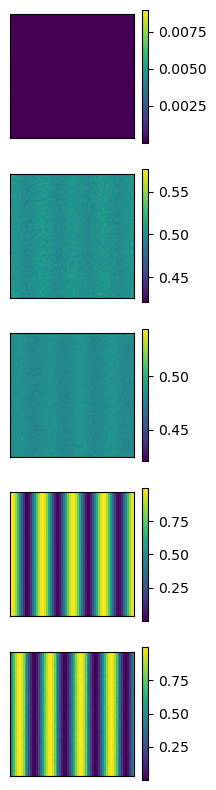

In [9]:
fig, ax = plt.subplots(5,1, figsize=(2,10))
minIn = 0
maxIn = 1

ax[0].pcolormesh(full_meas[:,:,0], vmin=minIn, vmax=maxIn) 
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].pcolormesh(full_meas[:,:,1], vmin=minIn, vmax=maxIn) 
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

ax[2].pcolormesh(full_meas[:,:,2], vmin=minIn, vmax=maxIn) 
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

ax[3].pcolormesh(full_meas[:,:,3], vmin=minIn, vmax=maxIn)
ax[3].get_xaxis().set_visible(False)
ax[3].get_yaxis().set_visible(False)

ax[4].pcolormesh(full_meas[:,:,4], vmin=minIn, vmax=maxIn)
ax[4].get_xaxis().set_visible(False)
ax[4].get_yaxis().set_visible(False)

# Add colorbars to subplots

cb1 = fig.colorbar(ax[0].imshow(full_meas[:,:,0]), ax=ax[0])
cb2 = fig.colorbar(ax[1].imshow(full_meas[:,:,1]), ax=ax[1])
cb3 = fig.colorbar(ax[2].imshow(full_meas[:,:,2]), ax=ax[2])
cb4 = fig.colorbar(ax[3].imshow(full_meas[:,:,3]), ax=ax[3])
cb5 = fig.colorbar(ax[4].imshow(full_meas[:,:,4]), ax=ax[4])


In [ ]:
np.max(full_meas[:,:,1])

As you can see, we do indeed observe *singular* behavior in the phi plots! This is not seen in nx and ny 

# Now we prompt the network to make predictions on the theoretical data

In [ ]:
full_meas_enhance = tf.expand_dims(full_meas, axis=0)

# Initiate predictions
start_time = time.time()
y_pred=loaded_model.predict(full_meas_enhance)
fin_time = time.time() - start_time
print(fin_time)

En_vect = y_pred[0,:,:,0]
nx_vect = np.sin(y_pred[0,:,:,1])*np.cos(y_pred[0,:,:,2])
ny_vect = np.sin(y_pred[0,:,:,1])*np.sin(y_pred[0,:,:,2])
nz_vect = np.cos(y_pred[0,:,:,1])

a1_synthPred = y_pred[0,:,:,0]
a2_synthPred = y_pred[0,:,:,1]
a3_synthPred = y_pred[0,:,:,2]


En_vect_t = np.transpose(En_vect)
nx_vect_t = np.transpose(nx_vect)
ny_vect_t = np.transpose(ny_vect)
nz_vect_t = np.transpose(nz_vect)


# To gain an intuition, compute the mean squared error between synthetic and numerical experiments

In [ ]:
full_meas_synthPred = full_measure(a1_synthPred,a2_synthPred,a3_synthPred,num_pix,noise,stateNoise)

Plot numerical vs. synthetic experiments

In [ ]:
fig, ax = plt.subplots(2,5, figsize=(20,8))

c = ax[0,0].imshow(full_meas[:,:,0])
ax[0,0].set_title('Synthentic', fontsize=24)
cbar=fig.colorbar(c, ax=ax[0,0])

c1 = ax[1,0].imshow(full_meas_synthPred[:,:,0])
ax[1,0].set_title('Numerical', fontsize=24)
cbar=fig.colorbar(c1, ax=ax[1,0])

c2 = ax[0,1].imshow(full_meas[:,:,1])
cbar=fig.colorbar(c2, ax=ax[0,1])

c3= ax[1,1].imshow(full_meas_synthPred[:,:,1])
cbar=fig.colorbar(c3, ax=ax[1,1])

c4 = ax[0,2].imshow(full_meas[:,:,2])
cbar=fig.colorbar(c4, ax=ax[0,2])

c5 = ax[1,2].imshow(full_meas_synthPred[:,:,2])
cbar=fig.colorbar(c5, ax=ax[1,2])

c6 =ax[0,3].imshow(full_meas[:,:,3])
cbar=fig.colorbar(c6, ax=ax[0,3])

c7 =ax[1,3].imshow(full_meas_synthPred[:,:,3])
cbar=fig.colorbar(c7, ax=ax[1,3])

c8= ax[0,4].imshow(full_meas[:,:,4])
cbar=fig.colorbar(c8, ax=ax[0,4])

c9 =ax[1,4].imshow(full_meas_synthPred[:,:,4])
cbar=fig.colorbar(c9, ax=ax[1,4])

plt.savefig('hmmm.png')

Compute error

In [ ]:
MSE = np.square(np.subtract(full_meas,full_meas_synthPred)).mean()

In [ ]:
mse_0 = mean_squared_error(full_meas[:,:,0], full_meas_synthPred[:,:,0])
mse_1 = mean_squared_error(full_meas[:,:,1], full_meas_synthPred[:,:,1])
mse_2 = mean_squared_error(full_meas[:,:,2], full_meas_synthPred[:,:,2])
mse_3 = mean_squared_error(full_meas[:,:,3], full_meas_synthPred[:,:,3])
mse_4 = mean_squared_error(full_meas[:,:,4], full_meas_synthPred[:,:,4])

print(f'LL: {mse_0}\nLH: {mse_1}\nLD: {mse_2}\nHH: {mse_3} \nHD: {mse_4}')
print(f'Absolute Error: {MSE}')

# Theoretical vs. Predicted vs. Experimental Predictions

In [ ]:
# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minTheta = 0
maxTheta = np.pi

minPhi = 0
maxPhi = 2*np.pi

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(3,3,figsize=(20, 10))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Theoretical vs. Predicted vs. Experimental Results')

c4 = ax[0,0].pcolormesh(x, y, a1, cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[0,0])

c5 = ax[0,1].pcolormesh(x, y, a2, cmap='viridis', vmin=minTheta, vmax=maxTheta)
ax[0,1].set_title('a2 plot')
# set the limits of the plot to the limits of the data
ax[0,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c5, ax=ax[0,1])

c6 = ax[0,2].pcolormesh(x, y, a3, cmap='hsv', vmin=minPhi, vmax=maxPhi)
ax[0,2].set_title('a3 plot')
# set the limits of the plot to the limits of the data
ax[0,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c6, ax=ax[0,2])

c = ax[1,0].pcolormesh(x, y, y_pred[0,:,:,0], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[1,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[1,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[1,0])

c2 = ax[1,1].pcolormesh(x, y, y_pred[0,:,:,1], cmap='viridis', vmin=minTheta, vmax=maxTheta)
ax[1,1].set_title('a2 plot')
# set the limits of the plot to the limits of the data
ax[1,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1,1])

c3 = ax[1,2].pcolormesh(x, y, y_pred[0,:,:,2], cmap='hsv', vmin=minPhi, vmax=maxPhi)
ax[1,2].set_title('a3 plot')
# set the limits of the plot to the limits of the data
ax[1,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[1,2])

c7 = ax[2,0].pcolormesh(x, y, y_exp[0,:,:,0], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[2,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[2,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[2,0])

c8 = ax[2,1].pcolormesh(x, y, y_exp[0,:,:,1], cmap='viridis', vmin=minTheta, vmax=maxTheta)
ax[2,1].set_title('a2 plot')
# set the limits of the plot to the limits of the data
ax[2,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[2,1])

c9 = ax[2,2].pcolormesh(x, y, y_exp[0,:,:,2], cmap='hsv', vmin=minPhi, vmax=maxPhi)
ax[2,2].set_title('a3 plot')
# set the limits of the plot to the limits of the data
ax[2,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2,2])


plt.savefig('spherical_eigenstate_predictions_hsv.png')

# Simulated vs. Actual Predictions

In [ ]:
# Transpose the matrix

En_th_t = np.transpose(E_th_mat)
nx_th_t = np.transpose(nx_th_mat)
ny_th_t = np.transpose(ny_th_mat)
nz_th_t = np.transpose(nz_th_mat)

# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minNx = -1
maxNx = 1

minNy = -1
maxNy = 1

minNz = -1
maxNz = 1

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(3,4,figsize=(20, 10))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Theoretical (top) vs.Experimental (bottom) Results of Reconstruction')

c = ax[0,0].pcolormesh(x, y, En_th_t[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0,0])

c2 = ax[0,1].pcolormesh(x, y, nx_th_t[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[0,1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[0,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[0,1])

c3 = ax[0,2].pcolormesh(x, y, ny_th_t[:-1,:-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[0,2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[0,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[0,2])

c4 = ax[0,3].pcolormesh(x, y, nz_th_t[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[0,3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[0,3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[0,3])

c5 = ax[1,0].pcolormesh(x, y,  En_vect_t[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[1,0])

c6 = ax[1,1].pcolormesh(x, y,  nx_vect_t[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[1,1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1,1])

c7 = ax[1,2].pcolormesh(x, y,  ny_vect_t[:-1, :-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[1,2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[1,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[1,2])

c8 = ax[1,3].pcolormesh(x, y, nz_vect_t[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[1,3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[1,3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[1,3])

c9 = ax[2,0].pcolormesh(x, y,  En_exp_t[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[2,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[2,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[2,0])

c10 = ax[2,1].pcolormesh(x, y,  nx_exp_t[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[2,1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[2,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[2,1])

c11 = ax[2,2].pcolormesh(x, y,  ny_exp_t[:-1, :-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[2,2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[2,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2,2])

c12 = ax[2,3].pcolormesh(x, y, nz_exp_t[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[2,3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[2,3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[2,3])

# How well does the Network fare with other Synthetic Processes?

In [ ]:
num_pix = 32

direcs = [f'synthetic_experiments_{num_pix}/{ii}/' for ii in range(1,9)] # Synthetic experiments
synth = 5

if (synth==5):
    a2 = np.ones((num_pix,num_pix))*np.pi/2
else:
    a2 = np.loadtxt(direcs[synth-1]+'theta.txt')
    
a1 = np.loadtxt(direcs[synth-1]+'en.txt')
a3 = np.loadtxt(direcs[synth-1]+'phi.txt')

LL = np.loadtxt(direcs[synth-1]+'LL.txt')
LH = np.loadtxt(direcs[synth-1]+'LH.txt')
LD = np.loadtxt(direcs[synth-1]+'LD.txt')
HH = np.loadtxt(direcs[synth-1]+'HH.txt')
HD = np.loadtxt(direcs[synth-1]+'HD.txt')

full_meas = np.empty((num_pix,num_pix,5))

for i in range(num_pix):
    for j in range(num_pix):
        full_meas[i,j,0] = LL[i,j]
        full_meas[i,j,1] = LH[i,j]
        full_meas[i,j,2] = LD[i,j]
        full_meas[i,j,3] = HH[i,j]
        full_meas[i,j,4] = HD[i,j]

full_meas_enhance = tf.expand_dims(full_meas, axis=0)


Theoretical Predictions

In [ ]:
E_th_mat=a1
nx_th_mat=np.sin(a2)*np.cos(a3)
ny_th_mat=np.sin(a2)*np.sin(a3)
nz_th_mat=np.cos(a2)


Prompt the network to make predictions

In [ ]:
# Load the network 

mol_64 = 'network64_30'
mol_128 = 'network128_8batch'
mol_128_16 = 'network128_16batch'
mol_128_uniform= 'network128_uniform'
mol_128_uniPer = 'network128_uniform_new'
mol_128_new = '128Net_Uni'
mol_128_fixed = '128Net_Fixed'

mol_16_cycleLoss = '16Net_cycleMSE_100k'
mol_16_poly = '16Net_npoly'
mol_16_linear = '16Net_linear5'
mol_16_ctop = '16Net_cartToPoly'

mol_32_cycleLoss = '32Net_cycleMSE_100k'
mol_64_cycleLoss = '64Net_16U_20k'
mol_128_cycleLoss = '128Net_16U_10k'
mol_128_ctop = '128Net_fromCart'

mol_32_allRand_oneFourier = '32Net_allRand_oneFourier'
mol_32_allRand_twoFourier = '32Net_allRand_twoFourier'
mol_32_allRand_fourFourier = '32Net_allRand_fourFourier'

mol_64_allRand_100k = '64Net_allRand_100k'
mol_64_allRand_50k = '64Net_allRand_50k'
mol_64_allRand_50k_32U = '64Net_allRand_50k_32U'
mol_64_allRand_25k = '64Net_allRand'

mol_128_allRand = '128Net_allRand'

loaded_model = tf.keras.models.load_model(mol_32_allRand_fiveFourier, custom_objects={'math': math, 'minMean': avg_fidelity_loss, 'minMeanNormal':avg_norm_loss, 'mse_cyclic_2':mse_cyclic_2}, compile=True)

start_time = time.time()
y_pred=loaded_model.predict(full_meas_enhance)
fin_time = time.time() - start_time
print(fin_time)
np.shape(y_pred)

# Polar coordinate reconstruction

print("it is time")
En_vect=y_pred[0,:,:,0]
nx_vect=np.sin(y_pred[0,:,:,1])*np.cos(y_pred[0,:,:,2])
ny_vect=np.sin(y_pred[0,:,:,1])*np.sin(y_pred[0,:,:,2])
nz_vect=np.cos(y_pred[0,:,:,1])

# Compute the fidelity ... because we CAN

In [ ]:
def fidelity(mat1,mat2):
    prod=np.trace(np.dot(np.conjugate(mat1.T),mat2))
    
    return 0.5*np.abs(prod)

def op_par(En,nx,ny,nz):
    mat=np.zeros([2,2],dtype=complex)
    
    mat[0,0]=np.cos(En) - 1j*np.sin(En)*nz
    mat[0,1]=-1j*np.sin(En)*(nx - 1j*ny)
    mat[1,0]=-1j*np.sin(En)*(nx + 1j*ny)
    mat[1,1]=np.cos(En) + 1j*np.sin(En)*nz
    
    return mat

Fvals=np.zeros([num_pix,num_pix])

for i in range(num_pix):
    for j in range(num_pix):
            netU=op_par(En_vect[i,j],nx_vect[i,j],ny_vect[i,j],nz_vect[i,j])
            thU=op_par(E_th_mat[i,j],nx_th_mat[i,j],ny_th_mat[i,j],nz_th_mat[i,j])
            Fvals[i,j]=fidelity(netU,thU)
            
print(np.mean(Fvals))


Plot the predictions

In [ ]:
# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minTheta = 0
maxTheta = np.pi

minPhi = 0
maxPhi = 2*np.pi

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(2,3,figsize=(20, 10))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Theoretical vs. Predicted on Spherical Eigenstate Results')

c4 = ax[0,0].pcolormesh(x, y, a1, cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[0,0])

c5 = ax[0,1].pcolormesh(x, y, a2, cmap='viridis', vmin=minTheta, vmax=maxTheta)
ax[0,1].set_title('a2 plot')
# set the limits of the plot to the limits of the data
ax[0,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c5, ax=ax[0,1])

c6 = ax[0,2].pcolormesh(x, y, a3, cmap='viridis', vmin=minPhi, vmax=maxPhi)
ax[0,2].set_title('a3 plot')
# set the limits of the plot to the limits of the data
ax[0,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c6, ax=ax[0,2])

c = ax[1,0].pcolormesh(x, y, y_pred[0,:,:,0], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[1,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[1,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[1,0])

c2 = ax[1,1].pcolormesh(x, y, y_pred[0,:,:,1], cmap='viridis', vmin=minTheta, vmax=maxTheta)
ax[1,1].set_title('a2 plot')
# set the limits of the plot to the limits of the data
ax[1,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1,1])

c3 = ax[1,2].pcolormesh(x, y, y_pred[0,:,:,2], cmap='viridis', vmin=minPhi, vmax=maxPhi)
ax[1,2].set_title('a3 plot')
# set the limits of the plot to the limits of the data
ax[1,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[1,2])

